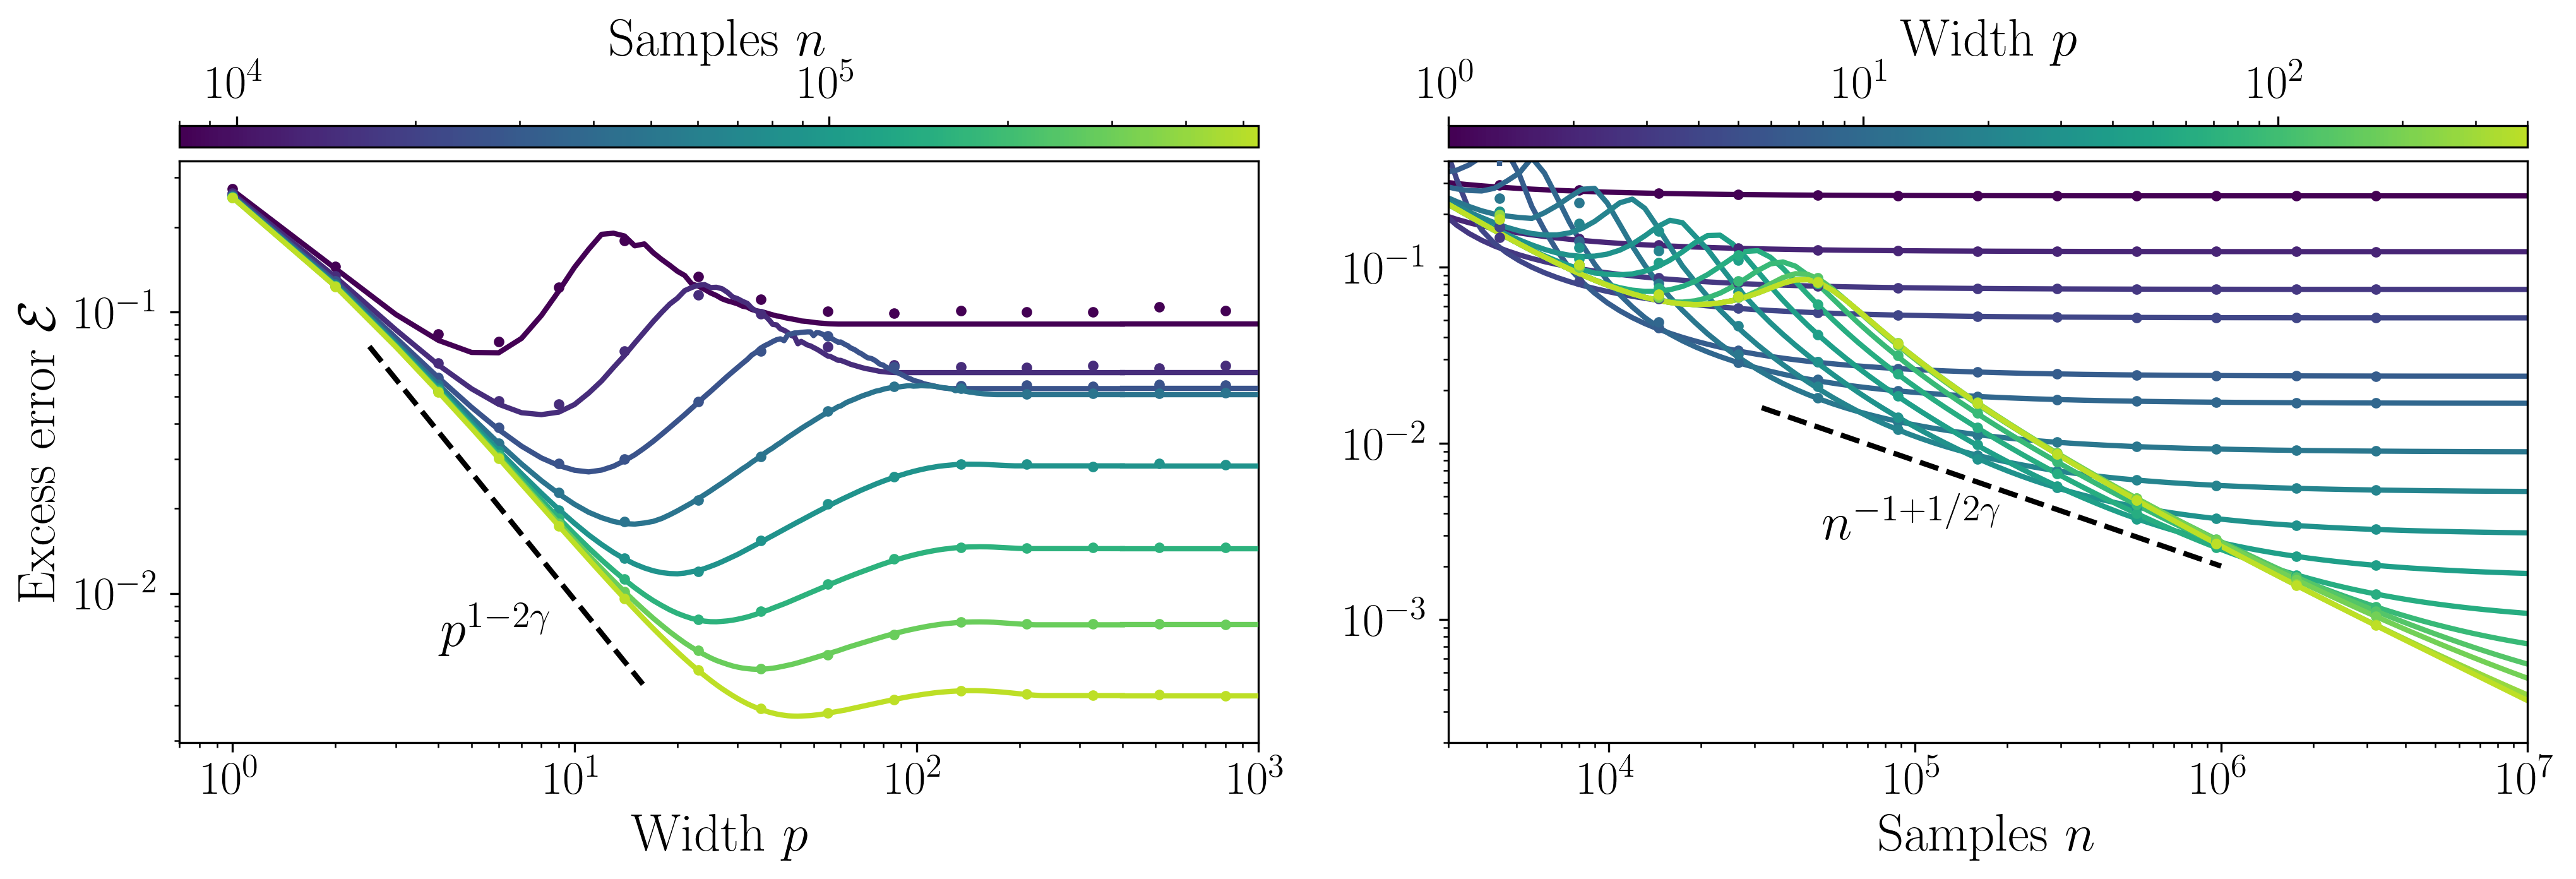

In [4]:
import os
import glob
import re

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd


# latex for nice plot labels
fs=20
plt.rcParams.update({
    'font.size': fs,
    'lines.linewidth': 2.0,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': int(fs * 0.9),
    'ytick.labelsize': int(fs * 0.9),
    'legend.fontsize': int(fs * 0.9),
    'figure.titlesize': fs,
    'text.usetex': True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})


# -----------------------------
# Helpers
# -----------------------------

def truncate_colormap(cmap, minval=0.0, maxval=0.9, n=256):
    return mpl.colors.LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n))
    )


def extract_float(pattern, string):
    match = re.search(pattern, string)
    if match is None:
        return None
    return float(match.group(1))


def extract_int(pattern, string):
    match = re.search(pattern, string)
    if match is None:
        return None
    return int(match.group(1))


# -----------------------------
# Parameters
# -----------------------------

d = 400
gamma = 1.25
noise = 0.1
lregref = 0.1

cmap = truncate_colormap(plt.cm.viridis, 0.0, 0.9)


# -----------------------------
# Figure
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)
fig.subplots_adjust(wspace=0.3)


# ============================================================
# Left panel: error vs width p, colored by samples n
# ============================================================

ax = axes[0]

se_rank_files = sorted(glob.glob(
    f"data_final/SE_rank_d{d}_n*_gamma{gamma}_noise{noise}_lregtilde*.csv"
))

# Extract n values from filenames
n_values = []
for f in se_rank_files:
    n = extract_float(r"_n([0-9.eE+-]+)_gamma", os.path.basename(f))
    if n is not None:
        n_values.append(n)

n_values = np.array(sorted(set(n_values)))

norm_n = mpl.colors.LogNorm(vmin=n_values.min(), vmax=n_values.max())

for i, n in enumerate(n_values):
    color = cmap(norm_n(n))

    # Find corresponding SE file
    se_matches = glob.glob(
        f"data_final/SE_rank_d{d}_n{n}_gamma{gamma}_noise{noise}_lregtilde*.csv"
    )

    if len(se_matches) > 0:
        df = pd.read_csv(se_matches[0])

        ax.plot(
            df["rank"],
            df["mse"],
            color=color,
            marker="",
            zorder=100 * i,
        )

        # horizontal continuation after p=d
        ax.plot(
            [d, 1000],
            [df["mse"].values[0], df["mse"].values[0]],
            linestyle="-",
            color=color,
            zorder=100 * i,
        )

    # Find corresponding EXP file
    exp_matches = glob.glob(
        f"data_final/EXP_rank_d{d}_n{n}_gamma{gamma}_noise{noise}_lregtilde*.csv"
    )

    if len(exp_matches) > 0:
        df = pd.read_csv(exp_matches[0])

        ax.errorbar(
            df["rank"],
            df["mse_mean"],
            yerr=df["mse_std"],
            linestyle="",
            marker=".",
            color=color,
            zorder=100 * i + 1,
        )


ax.set_xlim(0.7, 1e3)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Width $p$")
ax.set_ylabel(r"Excess error $\mathcal{E}$")

# scaling guide
axes[0].text(4e0, 6e-3, r"$p^{1 - 2\gamma}$", ha="left", va="bottom")
xbasis = np.logspace(0.4, 1.2, 10)
axes[0].plot(
    xbasis,
    3e-1 * xbasis ** (1 - 2 * gamma),
    linestyle="--",
    color="black",
)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_n)
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    location="top",
    aspect=50,
)
cbar.set_label(r"Samples $n$")


# ============================================================
# Right panel: error vs samples n, colored by width p
# ============================================================

ax = axes[1]

se_sample_files = sorted(glob.glob(
    f"data_final/SE_samples_d{d}_rank*_gamma{gamma}_noise{noise}_lregref_{lregref}.csv"
))

rank_values = []
for f in se_sample_files:
    rank = extract_int(r"_rank([0-9]+)_gamma", os.path.basename(f))
    if rank is not None:
        rank_values.append(rank)

rank_values = np.array(sorted(set(rank_values)))

norm_rank = mpl.colors.LogNorm(vmin=rank_values.min(), vmax=rank_values.max())

for i, rank in enumerate(rank_values):
    color = cmap(norm_rank(rank))

    se_file = (
        f"data_final/SE_samples_d{d}_rank{rank}_gamma{gamma}"
        f"_noise{noise}_lregref_{lregref}.csv"
    )

    if os.path.exists(se_file):
        df = pd.read_csv(se_file)

        ax.plot(
            df["n"],
            df["mse"],
            color=color,
            label=rf"$p={rank}$",
        )

    exp_file = (
        f"data_final/EXP_samples_d{d}_rank{rank}_gamma{gamma}"
        f"_noise{noise}_lregref_{lregref}.csv"
    )

    if os.path.exists(exp_file):
        df = pd.read_csv(exp_file)

        ax.errorbar(
            df["n"],
            df["mse_mean"],
            yerr=df["mse_std"],
            linestyle="",
            marker=".",
            color=color,
            zorder=100 * i + 1,
        )


# scaling guide
ax.text(5e4, 2.5e-3, r"$n^{-1 + 1/2\gamma}$", ha="left", va="bottom")
xbase = np.logspace(4.5, 6, 10)
ax.plot(
    xbase,
    0.8e1 * xbase ** (-1 + 1 / (2 * gamma)),
    linestyle="--",
    color="black",
)

ax.set_xlim(3e3, 1e7)
ax.set_ylim(2e-4, 4e-1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Samples $n$")

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_rank)
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    location="top",
    aspect=50,
)
cbar.set_label(r"Width $p$")


# -----------------------------
# Final layout/save
# -----------------------------

plt.tight_layout()
plt.savefig("images/figure_1.pdf", bbox_inches="tight")
plt.show()

1.2


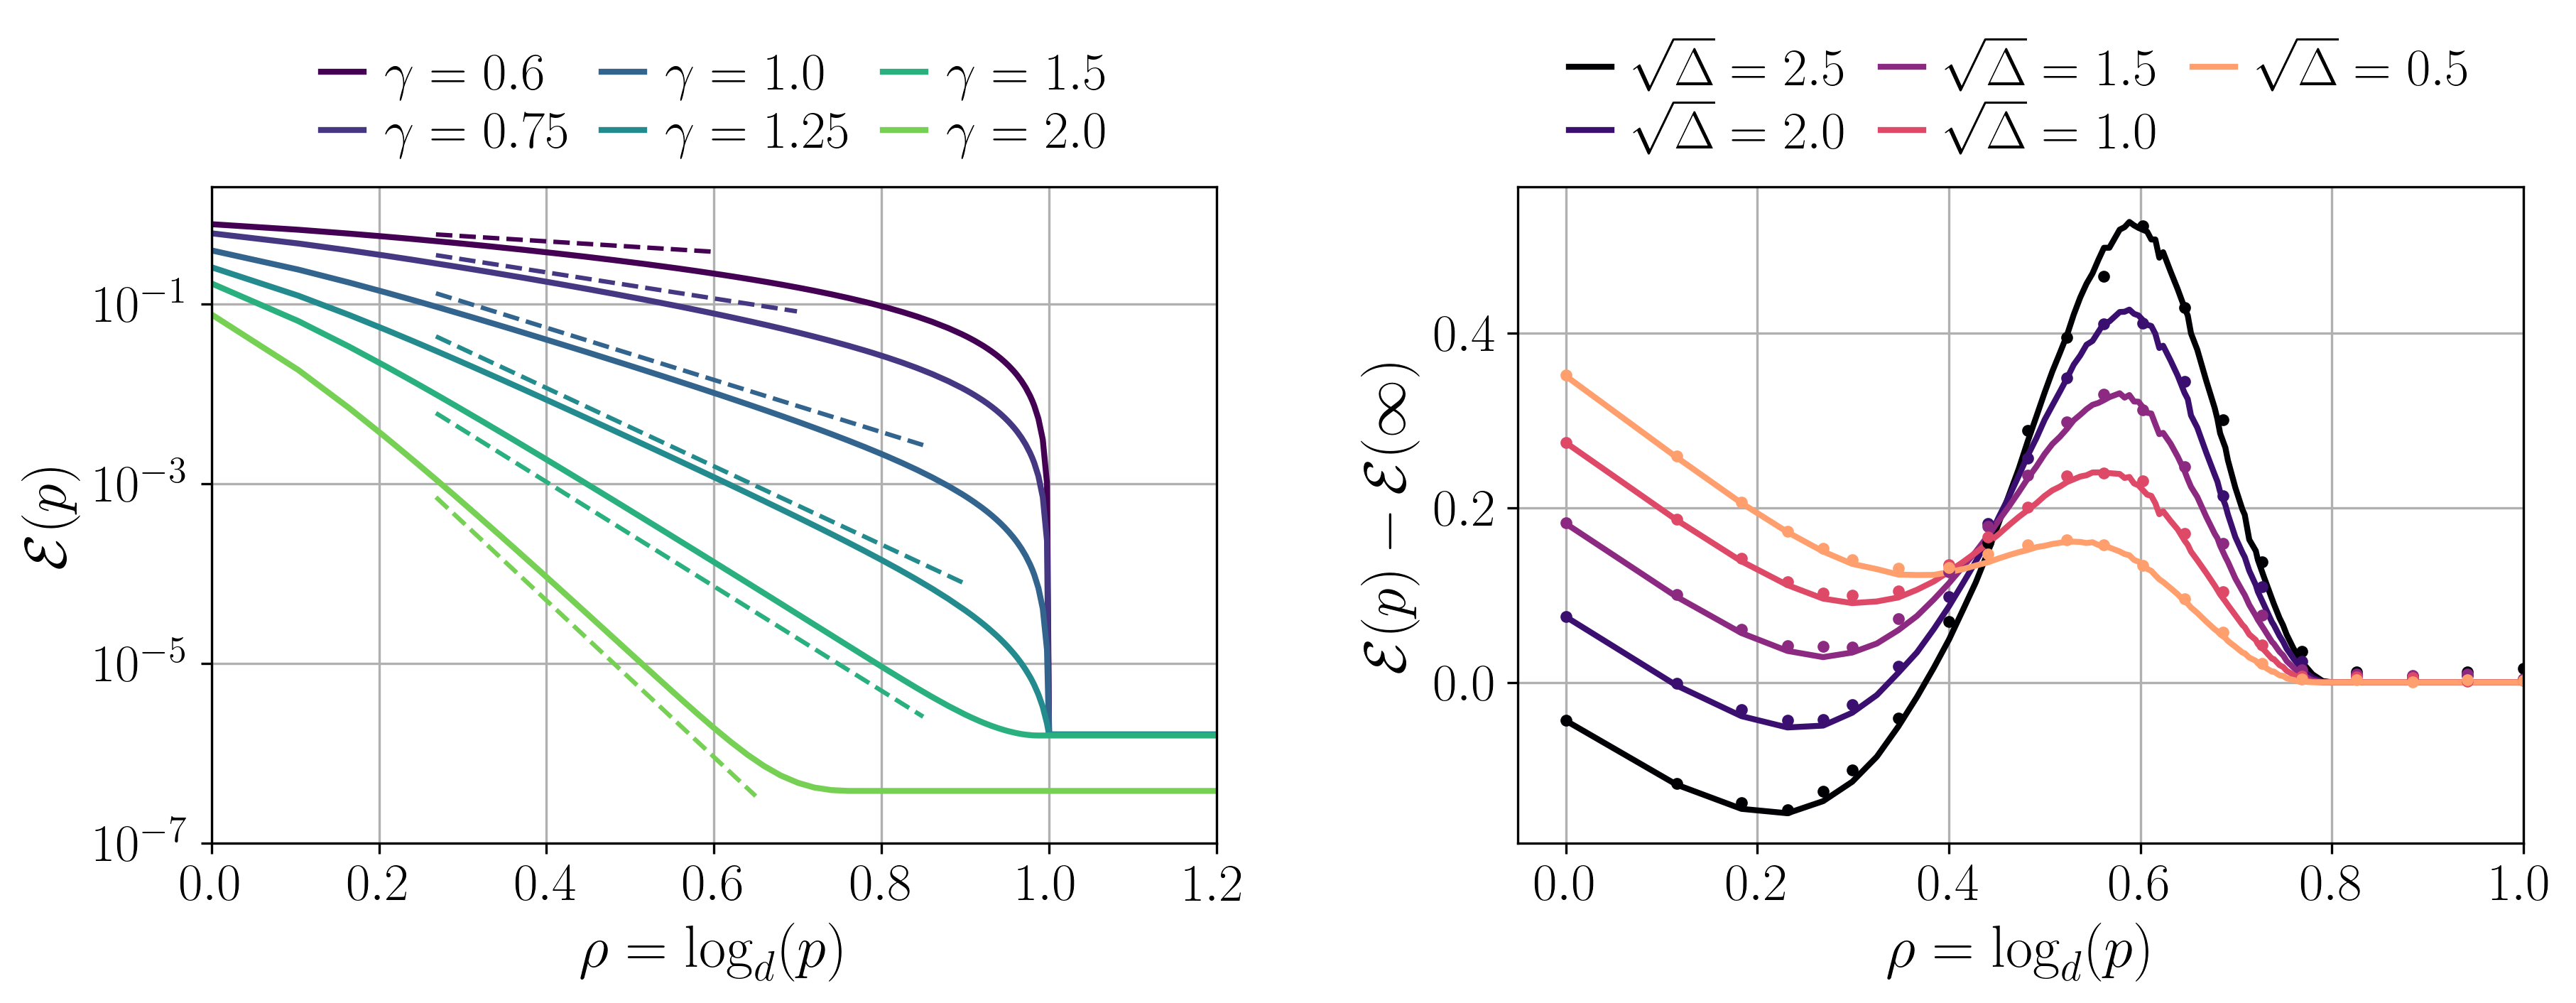

In [3]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.gridspec as gridspec



def rho_eff2(alpha,gamma,ell):
    return min(1,(alpha-ell-3/2)/gamma)

kappa_teacher=1.0
gammavals=np.array([0.6,0.75,1.0,1.25,1.5,2.0])
colors = plt.cm.viridis(np.linspace(0, 0.95, len(gammavals)+1))
fs=20
plt.rcParams.update({
    'font.size': fs,
    'lines.linewidth': 2.0,
    'axes.titlesize': fs,
    'axes.labelsize': fs,
    'xtick.labelsize': int(fs * 0.9),
    'ytick.labelsize': int(fs * 0.9),
    'legend.fontsize': int(fs * 0.9),
    'figure.titlesize': fs,
    'text.usetex': True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

d=800
alphaleft=4.0
noise=0.5
ellleft=alphaleft/2-0.8

fig,axs=plt.subplots(1, 2, figsize=(14, 4),dpi=300)
fig.subplots_adjust(wspace=0.3)
print(ellleft)
n=int(d**alphaleft)

for i, gamma in enumerate(gammavals):
    lreg=d**ellleft
    filename=f"data_final/SE_samples_d{d}_n{float(n)}_gamma{gamma}_noise{noise}_lregexp_{ellleft:.2f}.csv"
    if os.path.exists(filename):
        se_exists=True
        df_erm = pd.read_csv(filename,usecols=['rank','mse'])
        df_erm.dropna(inplace=True)
        df_erm.sort_values(by='rank', inplace=True)
        df_erm = df_erm.groupby('rank').mean().reset_index()
        idx= df_erm['rank']>=1 
        df_erm=df_erm[idx]
        axs[0].plot(np.log10(df_erm['rank'])/np.log10(d), df_erm['mse'], '-', color=colors[i], label=rf'$\gamma={gamma}$')
        ranks_erm=df_erm['rank'].values
        rs=np.array(range(1, d+1))

        try:
            rho_idx=np.where(ranks_erm==rs[0])[0][0]
        except IndexError:
            print(f"Warning: rs[0]={rs[0]} not found in ranks_erm.")
            rho_idx=0  # default to the first index if not found

        Cd=np.sqrt(d/np.sum(np.arange(1,1+d)**(-2*gamma)))
        y=rs**(1-2*gamma)
        y=y/y[rho_idx]*df_erm['mse'].values[rho_idx]
        rhomin=0.25
        if gamma==0.6:
            y *= 1.1
            rhomax=0.6
        elif gamma==0.75:
            y *= 1.4
            rhomax=0.7
        elif gamma==1.0:
            y *= 2
            rhomax=0.85
        elif gamma==1.25:
            y *= 2.5
            rhomax=0.9
        elif gamma==1.5:
            y *= 1.3
            rhomax=0.85
        elif gamma==2.0:
            rhomax=0.65
            y *= 2

        rhos=np.log10(rs)/np.log10(d)
        idx=(rhos>=rhomin) & (rhos<=rhomax)

        axs[0].plot(rhos[idx], y[idx], '--',color=colors[i],linewidth=1.5)
    else:
        print(f"File {filename} not found.")





axs[0].set_xlabel(r'$\rho=\log_d(p)$')
axs[0].set_ylabel(r'$\mathcal{E}(p)$',labelpad=5)
axs[0].grid(True)
axs[0].set_yscale('log')
axs[0].set_xlim(left=0.0,right=1.2)
axs[0].legend(loc='lower center',
              bbox_to_anchor=(0.5, 1.05),
              borderaxespad=-0.5,
              frameon=False,
              ncol=3,
              columnspacing=0.6,    # reduce horizontal gap between columns
              handlelength=0.8,     # shorten legend line segments
              handletextpad=0.4,    # reduce space between handle and text
              labelspacing=0.2)     # reduce vertical space (if multiple rows)##fig.subplots_adjust(right=0.78)

alpha=1.7
ellright=alpha/2-1.0
noise=0.3
gamma=0.6
d=400
noises=[2.5,2.0,1.5,1.0,0.5]
colors=plt.cm.magma(np.linspace(0, 1.0, len(noises)+1))
lreg=d**ellright
n=int(d**alpha)
for i, noise in enumerate(noises):
    filename=f"data_final/SE_samples_d{d}_n{float(n)}_gamma{gamma}_noise{noise}_lregexp_{ellright:.2f}.csv"
    if os.path.exists(filename):
        se_exists=True
        df_erm = pd.read_csv(filename,usecols=['rank','mse'])
        df_erm.dropna(inplace=True)
        df_erm.sort_values(by='rank', inplace=True)
        df_erm = df_erm.groupby('rank').mean().reset_index()
        mse_plateau=df_erm['mse'].values[np.argmax(df_erm['rank'].values)]
        idx= df_erm['rank']>=1 
        df_erm=df_erm[idx]
        mses=df_erm['mse'].values-mse_plateau
        axs[1].plot(np.log10(df_erm['rank'])/np.log10(d), mses, '-', label=rf'$\sqrt\Delta={noise}$',color=colors[i],linewidth=2.0)
    else:
        print(f"File {filename} not found.")

    solver="LBFGS"
    folder=f"data_{solver}lowrank_ltilde/logd(n)={alpha:.3f}/logd(ltilde)_{ellright:.2f}/"
    filename=f"data_final/EXP_rank_d{d}_n{float(n)}_gamma{gamma}_noise{noise}_lregexp{ellright:.2f}.csv"

    if os.path.exists(filename):
        df = pd.read_csv(filename)
        df.dropna(inplace=True)
        df.sort_values(by='rank', inplace=True)
        df = df.groupby('rank').mean().reset_index()
  
        idx= df['rank']>=1
        df=df[idx]
        mses=df['mse_mean'].values-mse_plateau
        axs[1].errorbar(np.log10(df['rank'])/np.log10(d), mses, yerr=df['mse_std'].values, linewidth=0.0, marker='.', color=colors[i])
    else:
        pass
        #print(f"File {filename} not found.")
   

axs[1].set_xlabel(r'$\rho=\log_d(p)$')
axs[1].set_ylabel(r'$\mathcal{E}(p)-\mathcal{E}(\infty)$',labelpad=5)
#axs[1].set_title(rf'd={d}, $\ell$={ellright:.2f}, $\gamma={gamma}$, $\alpha={alpha}$')
axs[1].grid(True)
# place the legend to the right of the right subplot (outside the axes) and make room
axs[1].legend(loc='lower center',
              bbox_to_anchor=(0.5, 1.05),
              borderaxespad=-0.5,
              ncol=3,
              columnspacing=0.6,    # reduce horizontal gap between columns
              frameon=False,
              handlelength=0.8,     # shorten legend line segments
              handletextpad=0.4,    # reduce space between handle and text
              labelspacing=0.2)     # reduce vertical space (if multiple rows)
#fig.subplots_adjust(right=0.78)
axs[1].set_xlim(left=-0.05,right=1)
axs[0].set_xlim(left=0.0,right=1.2)

axs[0].set_ylim(top= 2, bottom=1e-7)

plt.savefig("images/figure_2.pdf", bbox_inches="tight")
plt.show()